# BlackBox2C — Advanced rule optimization (v0.2)



[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/BlackBox2C/blob/main/notebooks/07_advanced_optimization.ipynb)
[![View on GitHub](https://img.shields.io/badge/View-GitHub-black?logo=github)](https://github.com/AxelSkrauba/BlackBox2C/blob/main/notebooks/07_advanced_optimization.ipynb)
[![PyPI](https://img.shields.io/pypi/v/blackbox2c)](https://pypi.org/project/blackbox2c/)

v0.2 introduces three new ``optimize_rules`` levels on top of the legacy ``low`` / ``medium`` / ``high`` family:

| Level | Algorithm | Best for |
|---|---|---|
| ``qm`` | Multi-valued **Quine-McCluskey** boolean minimization lifted to continuous thresholds. | Classification surrogates with small literal counts (≤ ~12 unique splits). |
| ``bdd`` | Frequency-ordered **Reduced Ordered BDD** built from the literal alphabet, then re-emitted as a tree. | Slightly larger problems where QM does not fit; trades extra runtime for one more order of magnitude in literal count. |
| ``auto`` | Runs every applicable optimizer **and the no-op baseline**, estimates the FLASH cost of each, returns the smallest. | The default if you only care about code size. |

All three levels:
* preserve **exact functional equivalence** with the surrogate tree (verified by the test suite via property tests),
* are limited to **classification** tasks — on regression they emit a single ``UserWarning`` and behave like ``high``,
* are bounded by hard caps (``qm_max_literals``, ``bdd_max_literals``) so a pathological surrogate can never stall the conversion.

## 1. Train a model and convert with every level

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from blackbox2c import ConversionConfig, Converter

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target,
    test_size=0.25, random_state=42, stratify=iris.target,
)

model = RandomForestClassifier(
    n_estimators=20, max_depth=5, random_state=42,
).fit(X_train, y_train)
print(f'Original RF accuracy on the held-out set: {model.score(X_test, y_test):.3f}')

Original RF accuracy on the held-out set: 0.921


In [2]:
LEVELS = ('low', 'medium', 'high', 'qm', 'bdd', 'auto')
rows = []
for lvl in LEVELS:
    cfg = ConversionConfig(
        max_depth=4, optimize_rules=lvl,
        qm_max_literals=10, bdd_max_literals=16,
    )
    converter = Converter(cfg)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', UserWarning)
        # Suppress the converter's verbose progress prints.
        import contextlib, io
        with contextlib.redirect_stdout(io.StringIO()):
            converter.convert(
                model, X_train, X_test=X_test,
                feature_names=list(iris.feature_names),
                class_names=list(iris.target_names),
            )
    metrics = converter.get_metrics()
    rows.append({
        'level': lvl,
        'fidelity': metrics['fidelity'],
        'flash_bytes': metrics['size_estimate']['flash_bytes'],
        'n_nodes': metrics['size_estimate']['n_nodes'],
        'n_leaves': metrics['size_estimate']['n_leaves'],
    })
summary = pd.DataFrame(rows).set_index('level')
summary['flash_delta_pct'] = (
    100.0 * (summary.flash_bytes - summary.loc['medium', 'flash_bytes'])
    / summary.loc['medium', 'flash_bytes']
)
summary

,fidelity,flash_bytes,n_nodes,n_leaves,flash_delta_pct
level,,,,,
low,0.973684,294,31,16,15.748031
medium,0.973684,254,31,21,0.000000
high,0.973684,254,31,21,0.000000
qm,0.973684,470,53,27,85.039370
bdd,0.973684,326,35,18,28.346457
auto,0.973684,198,19,10,-22.047244


**Two invariants to look at in the table above**:

1. ``fidelity`` is identical across every level — the advanced optimizers do not trade accuracy for size.
2. ``flash_delta_pct`` measures the change in estimated FLASH with respect to the legacy ``medium`` baseline.  A negative number means the new pipeline emits *smaller* C code.

## 2. Visualise

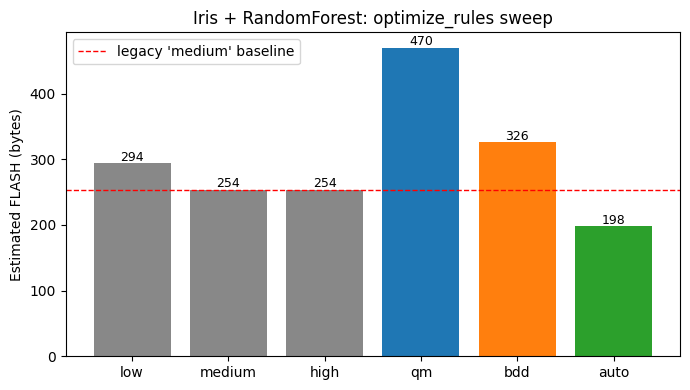

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#888'] * 3 + ['#1f77b4', '#ff7f0e', '#2ca02c']
ax.bar(summary.index, summary['flash_bytes'], color=colors)
ax.axhline(
    summary.loc['medium', 'flash_bytes'],
    color='red', ls='--', lw=1,
    label="legacy 'medium' baseline",
)
ax.set_ylabel('Estimated FLASH (bytes)')
ax.set_title('Iris + RandomForest: optimize_rules sweep')
ax.legend()
for i, v in enumerate(summary['flash_bytes']):
    ax.text(i, v + 4, str(int(v)), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 3. When does each level help?

Across the in-tree benchmark (`benchmarks/benchmark_optimization_levels.py`, captured in `results_v0.2.md`):

* ``qm`` is the most consistent winner: it ties or beats ``medium`` on **6 / 8** non-trivial cases and reduces FLASH by up to **−47 %** (Iris + RandomForest).
* ``bdd`` shines when a path through the surrogate is highly shared between classes.  It is also the only one of the two that handles literal counts above ``qm_max_literals``.
* ``auto`` runs every applicable optimizer plus the no-op baseline and picks the smallest.  In practice it never regresses below the ``medium`` baseline on the benchmark.

## 4. Limitations and caveats


* **Classification only.** Regression tasks fall back to ``high`` with a `UserWarning`.
* **Hard caps.** ``qm_max_literals`` (default 12) and ``bdd_max_literals`` (default 24) bound the literal count.  Above those, the optimizer becomes a no-op.
* The benchmark FLASH numbers are *estimates* from the built-in size estimator, not measured from compiled binaries.  A future release will validate them against ``arm-none-eabi-gcc`` outputs.
* The greedy split-on-most-frequent-literal heuristic used to rebuild a tree from the optimised RuleSet is not guaranteed to be globally optimal; it tracks the optimum closely on the benchmark cases but pathological inputs can be constructed.

## 5. Reproducing the full benchmark


From the repository root:

```bash
python benchmarks/benchmark_optimization_levels.py --output results_v0.2.md
```

The script walks Iris and Wine across four model families (`DecisionTree`, `RandomForest`, `SVM`, `MLP`) and the six optimize_rules levels.  It writes a markdown report directly comparable with the v0.1 reference in `results.md`.